## Agent2Agent 

In [22]:
#load the API

import os 
from dotenv import find_dotenv, load_dotenv

load_dotenv(find_dotenv(usecwd=True), override=True)
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
print("API Key Loaded:", os.getenv("GROQ_API_KEY")[:10] if os.getenv("GROQ_API_KEY") else "FAILED TO LOAD")

#Test the API KEY
from langchain_groq import ChatGroq
from langchain_openai import ChatOpenAI #alternative 

llm_model = ChatGroq(model ="llama-3.3-70b-versatile" )
print(llm_model.invoke("hello, tell me about yourself in few words").content)


API Key Loaded: gsk_8yEZ0T
I'm an AI, here to help and chat.


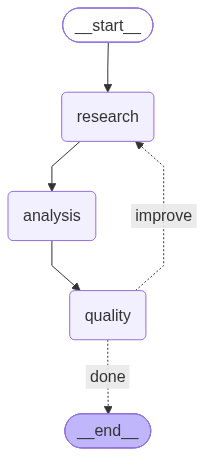

In [23]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# -----------------------------
# Shared State
# -----------------------------
class State(TypedDict):
    user_input: str
    answer: str
    feedback: str
    satisfactory: bool
    iteration: int


# -----------------------------
# Agent 1: Research Agent
# -----------------------------
def research_agent(state: State):

    print("\n🔎 Research Agent")
    user_input = state.get("user_input", "")
    feedback = state.get("feedback", "")

    prompt = f"""
    User request:{state['user_input']}

    Previous feedback: {state['feedback']}

    Provide a clear and accurate answer to the user's request.

    If feedback is provided, improve the previous answer
    based on that feedback.
    """
    response = llm_model.invoke(prompt)

    return {
        "answer": response.content,
        "iteration": state.get("iteration", 0) + 1
    }


# -----------------------------
# Agent 2: Analysis Agent
# -----------------------------
def analysis_agent(state: State):

    prompt = f"""
        Review the following answer for the user's request.

        User request:
        {state['user_input']}

        Answer:
        {state['answer']}

        Identify what is missing, incorrect, unclear,
        or could be improved.

        Give concise improvement feedback.
        """
    response = llm_model.invoke(prompt)

    return {"feedback": response.content}


# -----------------------------
# Agent 3: Quality Agent
# -----------------------------
def quality_agent(state: State):

    print("✅ Quality Agent")
    prompt = f"""
        You are a quality evaluator.

        User request:
        {state['user_input']}

        Answer:
        {state['answer']}

        Reviewer feedback:
        {state['feedback']}

        Decide whether the answer is satisfactory.

        Respond ONLY with:
        YES
        or
        NO
        """

    response = llm_model.invoke(prompt)
    decision = response.content.strip().upper()

    if "YES" in decision:
        print("Result is satisfactory!")
        return {"satisfactory": True}

    print("Result needs improvement.")

    return {"satisfactory": False}

# -----------------------------
# Routing Logic
# -----------------------------
def check_quality(state: State):

    # Safety limit to prevent infinite loops
    if state["satisfactory"] or state["iteration"] >= 3:
        return "done"

    return "improve"


# -----------------------------
# Build LangGraph
# -----------------------------

graph = StateGraph(State)

graph.add_node("research", research_agent)
graph.add_node("analysis", analysis_agent)
graph.add_node("quality", quality_agent)

graph.add_edge(START, "research")
graph.add_edge("research","analysis")
graph.add_edge("analysis", "quality")

graph.add_conditional_edges("quality",check_quality,
    {
        "improve": "research",
        "done": END
    }
)

app = graph.compile()
app



In [26]:

# -----------------------------
# Run
# -----------------------------

user_input = input("User: ")

result = app.invoke({
    "user_input": user_input,
    "result": "",
    "feedback": "",
    "satisfactory": False,
    "iteration": 0
})

print("\nFinal Result:")
print(result)


🔎 Research Agent
✅ Quality Agent
Result needs improvement.

🔎 Research Agent
✅ Quality Agent
Result needs improvement.

🔎 Research Agent
✅ Quality Agent
Result needs improvement.

Final Result:
{'user_input': 'give me more info about ai', 'answer': '**Introduction to Artificial Intelligence (AI)**\n\nArtificial Intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, decision-making, and perception. AI involves a broad range of techniques, including machine learning, deep learning, natural language processing, and computer vision.\n\n**Types of AI**\n\nThere are several types of AI, including:\n\n1. **Narrow or Weak AI**: Designed to perform a specific task, such as facial recognition or language translation.\n2. **General or Strong AI**: Aims to create a machine that can perform any intellectual task that a human can.\n3. **Superintelligence**: Significantly more intelligent th

In [28]:
result['answer']

'**Introduction to Artificial Intelligence (AI)**\n\nArtificial Intelligence (AI) refers to the development of computer systems that can perform tasks that typically require human intelligence, such as learning, problem-solving, decision-making, and perception. AI involves a broad range of techniques, including machine learning, deep learning, natural language processing, and computer vision.\n\n**Types of AI**\n\nThere are several types of AI, including:\n\n1. **Narrow or Weak AI**: Designed to perform a specific task, such as facial recognition or language translation.\n2. **General or Strong AI**: Aims to create a machine that can perform any intellectual task that a human can.\n3. **Superintelligence**: Significantly more intelligent than the best human minds, potentially leading to exponential growth in technological advancements.\n\n**How AI Works**\n\nAI systems rely on algorithms, data, and computing power to learn and improve over time. The process involves:\n\n1. **Data Colle